In [1]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np 
import matplotlib.pyplot as plt


In [3]:
import sys
print(sys.executable)

c:\Users\abdul\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [6]:
g = torch.Generator().manual_seed(SEED)

In [7]:
root= r'C:\Users\abdul\Desktop\Projekte\Python\Giris\dataset'
DATASET_NAME='CIFAR10'

In [8]:
base_train=datasets.CIFAR10(root=root, train=True, download=True, transform=None)
base_test=datasets.CIFAR10(root=root, train=False, download=True, transform=None)
classes=base_train.classes

#### Dataset

In [9]:
from re import S
from PIL import Image
from sympy.solvers.diophantine.diophantine import length


class CIFARDataset(Dataset):
    def __init__(self, ds, indices=None, transforms=None):
        self.data = ds.data
        self.targets = ds.targets

        if indices is None:
          self.indices = list(range(len(self.data)))
        else:
          self.indices = list(indices)
          
        self.transforms = transforms

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, target = self.data[self.indices[idx]], self.targets[self.indices[idx]]

        img = Image.fromarray(img)
        if self.transforms:
            img = self.transforms(img)
        return img, target



In [10]:
validation_ratio = 0.1
N = len(base_train)
validation_size = int(N * validation_ratio)

perm = torch.randperm(N, generator=g)
train_indices = perm[validation_size:].tolist()
val_indices = perm[:validation_size].tolist()

print('Base Train Size:', len(base_train) )
print('Validation Size:', validation_size) 
perm

Base Train Size: 50000
Validation Size: 5000


tensor([37542, 44491,   216,  ..., 40730, 25847, 33082])

In [11]:
mean, std = (0.4917, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [12]:
train_ds = CIFARDataset(base_train, indices=train_indices, transforms=train_transforms)
val_ds = CIFARDataset(base_train, indices=val_indices, transforms=val_transforms)
test_ds = CIFARDataset(base_test, transforms=val_transforms)

In [13]:
print("Train Size:", len(train_ds))
print("Validation Size:", len(val_ds))
print("Test Size:", len(test_ds))

Train Size: 45000
Validation Size: 5000
Test Size: 10000


####  Dataloader

In [14]:
BATCH_SIZE = 128
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=pin_memory, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=pin_memory, num_workers=0)

print("Train Loader Size:", len(train_loader))
print("Validation Loader Size:", len(val_loader))
print("Test Loader Size:", len(test_loader))
print("Pin_Memory:", pin_memory)

Train Loader Size: 352
Validation Loader Size: 40
Test Loader Size: 79
Pin_Memory: False


In [15]:
x, y = next(iter(train_loader))
print("Batch X shape:", x.shape)
print("Batch X dtype:", x.dtype)
print("Batch Y shape:", y.shape)
print("Batch Y dtype:", y.dtype)

Batch X shape: torch.Size([128, 3, 32, 32])
Batch X dtype: torch.float32
Batch Y shape: torch.Size([128])
Batch Y dtype: torch.int64


In [16]:
mean_t = torch.tensor(mean).view(len(mean),1 ,1)
std_t = torch.tensor(std).view(len(std),1 ,1)

def unnormalize(x_image):
    return x_image * std_t + mean_t

print(mean_t)
print(std_t)

tensor([[[0.4917]],

        [[0.4822]],

        [[0.4465]]])
tensor([[[0.2470]],

        [[0.2435]],

        [[0.2616]]])


In [17]:
grid = torchvision.utils.make_grid(unnormalize(x[:32]))

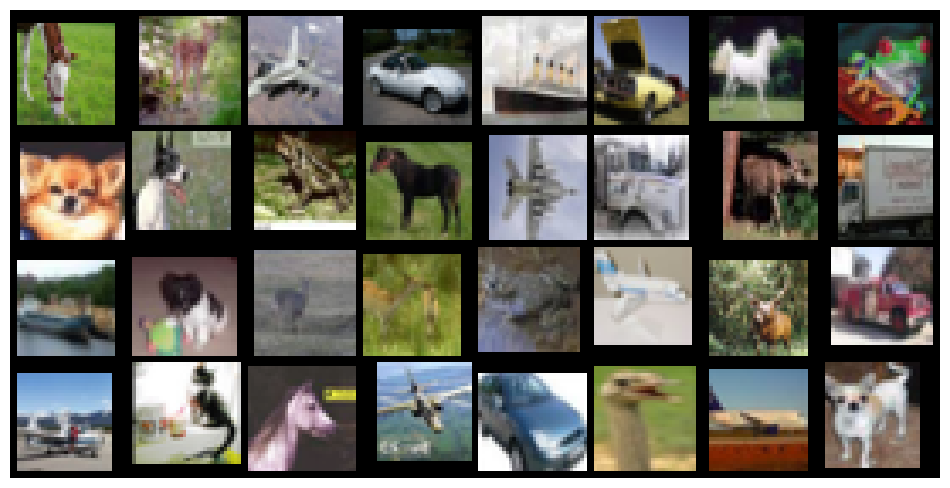

In [18]:
plt.figure(figsize=(12, 12))
if grid.shape[0] == 1:
    plt.imshow(grid.squeeze(0), cmap="gray")
else: 
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.show()

In [19]:
print("İlk 32 görüntünün sınıfları:", [classes[int(y)] for y in y[:32]])

İlk 32 görüntünün sınıfları: ['horse', 'deer', 'airplane', 'automobile', 'ship', 'automobile', 'horse', 'frog', 'dog', 'dog', 'frog', 'horse', 'airplane', 'truck', 'deer', 'truck', 'ship', 'dog', 'deer', 'deer', 'frog', 'airplane', 'deer', 'truck', 'airplane', 'cat', 'horse', 'airplane', 'automobile', 'bird', 'airplane', 'dog']


##### Training

In [20]:
from ders7_SmallModel import SmallCifarModel

model = SmallCifarModel(num_classes=len(classes), dropout=0.3)

model

SmallCifarModel(
  (Block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (Block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True

In [21]:
import torch.nn as nn

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_predictions

    return epoch_loss, epoch_accuracy

In [22]:
@torch.no_grad()
def evaluate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = correct_predictions / total_predictions

    return epoch_loss, epoch_accuracy

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [25]:
epochs = 20
file_path = "small_cifar_model.pt"

for epoch in range(1, epochs + 1):

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch:02d}: Train Loss {train_loss*100:.2f}, Train Acc {train_acc*100:.2f}, Val Loss {val_loss*100:.2f}, Val Acc {val_acc*100:.2f}")

    torch.save({
        "model_state": model.state_dict(),
        "epoch": epoch,
        "mean": mean,
        "std": std,
        "classes": classes,
        "arch" : "SmallCifarNet"
    }, file_path)

Epoch 01: Train Loss 192.49, Train Acc 29.20, Val Loss 146.26, Val Acc 46.52
Epoch 02: Train Loss 139.32, Train Acc 49.07, Val Loss 112.93, Val Acc 59.84
Epoch 03: Train Loss 114.72, Train Acc 58.95, Val Loss 103.73, Val Acc 62.28
Epoch 04: Train Loss 101.35, Train Acc 64.18, Val Loss 85.96, Val Acc 69.98
Epoch 05: Train Loss 92.70, Train Acc 67.68, Val Loss 80.12, Val Acc 71.12
Epoch 06: Train Loss 85.32, Train Acc 70.29, Val Loss 74.69, Val Acc 73.74
Epoch 07: Train Loss 78.87, Train Acc 72.75, Val Loss 70.04, Val Acc 75.40
Epoch 08: Train Loss 73.97, Train Acc 74.32, Val Loss 60.83, Val Acc 79.12
Epoch 09: Train Loss 69.98, Train Acc 76.01, Val Loss 61.41, Val Acc 79.00
Epoch 10: Train Loss 66.36, Train Acc 77.39, Val Loss 68.64, Val Acc 77.56
Epoch 11: Train Loss 62.67, Train Acc 78.76, Val Loss 60.11, Val Acc 79.92
Epoch 12: Train Loss 59.83, Train Acc 79.79, Val Loss 48.64, Val Acc 83.40
Epoch 13: Train Loss 56.87, Train Acc 80.71, Val Loss 57.53, Val Acc 81.06
Epoch 14: Train Lo